### Analytical Forward Model
##### combination of Sisson/Brooks-Corey analytical solution and forward model process for TDEM response

Imports

In [260]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import itertools
from simpeg import maps
from simpeg.electromagnetics import time_domain as tdem

Run Mode [known_soils, parameter_range]

In [261]:
run_mode = "known_soils" ### parameter_range

### 1. Define variables
##### 1.1 Soil Column and Timestamps

In [262]:
z = np.linspace(1, 600, 300)  # cm, positive downward
times = [1, 4, 12, 24, 48]   # hr

#### 1.2 ROSETTA/vG style soil parameter library

In [263]:
### set soil type parameter options for "truth" forward model

truth_soil_type = "sand"  ### options: custom, sand, loamy sand, sandy loam, loam, silt, silt loam, clay

### Custom option 
custom_vg_params = {
    "custom": {
    "theta_r": 0.05,
    "theta_s": 0.4,
    "alpha": 0.1,
    "n": 2.0,
    "Ks": 10.0,
    "l": 0.5
}}
### OR preset values for sand, loamy sand, sandy loam, loam, silt, silt loam, clay

known_soils = {
    "sand": {
        "theta_r": 0.045,
        "theta_s": 0.43,
        "alpha": 0.145,
        "vg_n": 2.68,
        "Ks": 29.7,
    },
    "loamy_sand": {
        "theta_r": 0.057,
        "theta_s": 0.41,
        "alpha": 0.124,
        "vg_n": 2.28,
        "Ks": 14.6,
    },
    "sandy_loam": {
        "theta_r": 0.065,
        "theta_s": 0.41,
        "alpha": 0.075,
        "vg_n": 1.89,
        "Ks": 4.42,
    },
    "loam": {
        "theta_r": 0.078,
        "theta_s": 0.43,
        "alpha": 0.036,
        "vg_n": 1.56,
        "Ks": 1.04,
    },
    "silt": {
        "theta_r": 0.085,
        "theta_s": 0.45,
        "alpha": 0.025,
        "vg_n": 1.35,
        "Ks": 0.52,
    },
    "silty_loam": {
        "theta_r": 0.09,
        "theta_s": 0.46,
        "alpha": 0.02,
        "vg_n": 1.25,
        "Ks": 0.35,
    }, 
    "clay": {
        "theta_r": 0.1,
        "theta_s": 0.47,
        "alpha": 0.015,
        "vg_n": 1.15,
        "Ks": 0.2,
    }      
}

### 1.2 Input Parameter Range 
##### Base around exsisting soils for correct drainage profiling

## 2. Analytical Solution
### 2.1 Conversion Functions

In [264]:
def vg_m(vg_n):
    """
    van Genuchten m parameter.
    """
    return 1 - (1 / vg_n)

def kr_van_genuchten_mualem(Se, vg_n, l=0.5):
    """
    van Genuchten-Mualem relative hydraulic conductivity.

    Se : effective saturation, between 0 and 1
    vg_n : van Genuchten n
    l : pore-connectivity/tortuosity parameter, commonly 0.5
    """
    Se = np.asarray(Se, dtype=float)
    Se = np.clip(Se, 1e-8, 1.0)

    m = vg_m(vg_n)

    Kr = Se**l * (1 - (1 - Se**(1 / m))**m)**2

    return Kr

### 2.2 Fitted Brooks-Corey Exponent for Each Soil Type

In [265]:
def fit_n_sisson_to_vg_mualem(vg_n, Se_min=0.1, Se_max=0.95, l=0.5):
    """
    Fit the Sisson/Brooks-Corey exponent n_sisson so that
    Kr = Se^(1/n_sisson) approximates the van Genuchten-Mualem curve.
    """

    Se = np.linspace(Se_min, Se_max, 300)
    Kr_vg = kr_van_genuchten_mualem(Se, vg_n=vg_n, l=l)

    # Avoid log of zero
    valid = (Kr_vg > 0) & (Se > 0)

    x = np.log(Se[valid])
    y = np.log(Kr_vg[valid])

    # Force fit through origin because log(Kr) = slope * log(Se)
    slope = np.sum(x * y) / np.sum(x * x)

    n_fit = 1 / slope

    return n_fit

In [266]:
for soil_name, item in known_soils.items():
    known_soils[soil_name]["bc_n_fitted"] = fit_n_sisson_to_vg_mualem(
        known_soils[soil_name]["vg_n"],
        Se_min=0.1,
        Se_max=0.95,
        l=0.5
    )

#### Setup "Truth" model [for eventual comparison]

### Choose parameters for "Truth"
#### Custom values OR sand, loamy sand, sandy loam, loam, silt, silt loam, clay

In [267]:
def truth_vg_params(soil_type):
    truth_soil_type = soil_type.lower().strip()
    if truth_soil_type in known_soils:
        return known_soils[truth_soil_type]
    elif truth_soil_type == "custom":
        return custom_vg_params["custom"]
    else:
        print(f"Warning: Unrecognized soil type '{soil_type}'. Defaulting to 'loam' parameters.")
        return known_soils["loam"]


truth_vg_params = truth_vg_params(
    soil_type=truth_soil_type,
    )

print(truth_vg_params)

{'theta_r': 0.045, 'theta_s': 0.43, 'alpha': 0.145, 'vg_n': 2.68, 'Ks': 29.7, 'bc_n_fitted': np.float64(0.2283884976669142)}


### %%%% Parameter ranges based off of exsisting known soil types [Look to edit later im not sure this is the best approach]

In [268]:
parameter_range_scenarios = {}
scenario_counter = 1

for soil_name, base_soil in known_soils.items():

    theta_r_values = [base_soil["theta_r"]]
    theta_s_values = [base_soil["theta_s"]]

    Ks_values = [
        base_soil["Ks"] * 0.75,
        base_soil["Ks"],
        base_soil["Ks"] * 1.25
    ]

    bc_n_values = [
        base_soil["bc_n_fitted"] * 0.9,
        base_soil["bc_n_fitted"],
        base_soil["bc_n_fitted"] * 1.1
    ]

    for theta_r, theta_s, Ks, bc_n in itertools.product(
        theta_r_values,
        theta_s_values,
        Ks_values,
        bc_n_values
    ):

        scenario_name = f"{soil_name}_scenario_{scenario_counter:03d}"

        parameter_range_scenarios[scenario_name] = {
            "base_soil": soil_name,
            "theta_r": theta_r,
            "theta_s": theta_s,
            "vg_n": base_soil["vg_n"],
            "Ks": Ks,
            "bc_n": bc_n,
            "q0": Ks
        }

        scenario_counter += 1

### Build Ensemble

#### Set Parameter Ranges to Creat Scenarios for Ensemble Run

In [269]:
"""### Generate parameter sets/range for ensemble runs
theta_r_values = [0.045, 0.057, 0.065, 0.078, 0.034, 0.067, 0.068]
theta_s_values = [0.43, 0.41, 0.41, 0.43, 0.46, 0.45, 0.38]
alpha_values = [0.145, 0.124, 0.075, 0.036, 0.016, 0.02, 0.008]
n_values = [2.68, 2.28, 1.89, 1.56, 1.37, 1.41, 1.09]
Ks_values = [29.7, 14.5917, 4.42083, 1.04, 0.25, 0.45, 0.2]
l_values = [0.5] DELETE PER CHAT""" 

'### Generate parameter sets/range for ensemble runs\ntheta_r_values = [0.045, 0.057, 0.065, 0.078, 0.034, 0.067, 0.068]\ntheta_s_values = [0.43, 0.41, 0.41, 0.43, 0.46, 0.45, 0.38]\nalpha_values = [0.145, 0.124, 0.075, 0.036, 0.016, 0.02, 0.008]\nn_values = [2.68, 2.28, 1.89, 1.56, 1.37, 1.41, 1.09]\nKs_values = [29.7, 14.5917, 4.42083, 1.04, 0.25, 0.45, 0.2]\nl_values = [0.5] DELETE PER CHAT'

### 2.3 Brooks-Corey Conductivity 

In [270]:
def K_brooks_corey(theta, theta_c, theta_m, K_m, bc_n):
    Se = (theta - theta_c) / (theta_m - theta_c)
    Se = np.clip(Se, 0, 1)

    K = K_m * Se ** (1 / bc_n)

    return K

### 2.4 Analytical Solution Sisson/Brooks-Corey 

In [271]:
if run_mode == "known_soils":

    scenarios_to_run = {
        soil_name: {
            "base_soil": soil_name,
            "theta_r": soil["theta_r"],
            "theta_s": soil["theta_s"],
            "vg_n": soil["vg_n"],
            "Ks": soil["Ks"],
            "bc_n": soil["bc_n_fitted"],
            "q0": soil["Ks"]
        }
        for soil_name, soil in known_soils.items()
    }

elif run_mode == "parameter_range":

    scenarios_to_run = parameter_range_scenarios.copy()

else:
    raise ValueError(
        "run_mode must be 'known_soils' or 'parameter_range'"
    )

In [272]:
def theta_brooks_corey_sisson_piecewise(
        z, t, theta_r, theta_s, Ks, bc_n, q0,
        return_star_mid=False,
        debug=False):

    z = np.asarray(z, dtype=float)

    if t <= 0:
        return np.full_like(z, theta_s)

    # Transformed depth for saturated initial condition
    z_star = (Ks / q0) ** bc_n * z

    # Sisson variable: z*/t
    s_star = np.maximum(z_star / t, 1e-12)

    # Brooks-Corey derivative setup
    A = Ks / (bc_n * (theta_s - theta_r))
    exponent = 1 / ((1 / bc_n) - 1)

    # Middle transformed solution
    theta_star_mid = theta_r + (theta_s - theta_r) * (s_star / A) ** exponent

    if debug:
        print("bc_n =", bc_n)
        print("Ks =", Ks)
        print("q0 =", q0)
        print("A =", A)
        print("exponent =", exponent)
        print("z_star min =", z_star.min())
        print("z_star max =", z_star.max())
        print("s_star min =", s_star.min())
        print("s_star max =", s_star.max())
        print("theta_star_mid min =", theta_star_mid.min())
        print("theta_star_mid max =", theta_star_mid.max())

    if return_star_mid:
        return theta_star_mid

    # Piecewise solution based on Sisson Eq. 15
    theta_star = np.empty_like(z)

    theta_star = np.clip(theta_star_mid, theta_r, theta_s)

    return theta_star

### Loop through each scenario for varrying parameters
#### edit fixed and changing parameters ***

In [273]:
theta_results = {}
results = []

for scenario_name, params in scenarios_to_run.items():

    print(
        f"Running {scenario_name}: "
        f"Ks={params['Ks']:.4f}, bc_n={params['bc_n']:.4f}"
    )

    theta_results[scenario_name] = {}

    for t in times:
        theta = theta_brooks_corey_sisson_piecewise(
            z=z,
            t=t,
            theta_r=params["theta_r"],
            theta_s=params["theta_s"],
            Ks=params["Ks"],
            bc_n=params["bc_n"],
            q0=params["q0"],
            debug=False
        )

        theta_results[scenario_name][t] = theta

    results.append({
        "scenario": scenario_name,
        "theta_r": params["theta_r"],
        "theta_s": params["theta_s"],
        "vg_n": params.get("vg_n", np.nan),
        "bc_n": params["bc_n"],
        "Ks": params["Ks"],
        "q0": params["q0"]
    })

results_df = pd.DataFrame(results)
results_df.to_csv("analytical_ensemble_summary.csv", index=False)

Running sand: Ks=29.7000, bc_n=0.2284
Running loamy_sand: Ks=14.6000, bc_n=0.2028
Running sandy_loam: Ks=4.4200, bc_n=0.1693
Running loam: Ks=1.0400, bc_n=0.1300
Running silt: Ks=0.5200, bc_n=0.0962
Running silty_loam: Ks=0.3500, bc_n=0.0762
Running clay: Ks=0.2000, bc_n=0.0522


## DRAINAGE CHECK
#### Ensure the scenarios act like drainage profiles before moving into TDEM response
#### Do the values decrease with time?

In [274]:
"""check_depth = 300
depth_index = np.argmin(np.abs(z - check_depth))

for scenario_name, time_dict in theta_results.items():

    theta_at_depth = []

    for t in times:
        theta_at_depth.append(time_dict[t][depth_index])

    print(scenario_name, theta_at_depth)"""

'check_depth = 300\ndepth_index = np.argmin(np.abs(z - check_depth))\n\nfor scenario_name, time_dict in theta_results.items():\n\n    theta_at_depth = []\n\n    for t in times:\n        theta_at_depth.append(time_dict[t][depth_index])\n\n    print(scenario_name, theta_at_depth)'

PLOTTING LOOP TO CHECK RESULTS 

In [275]:
"""for scenario_name, time_dict in theta_results.items():

    plt.figure(figsize=(6, 7))

    for t, theta in time_dict.items():
        plt.plot(theta, z, label=f"{t} hr")

    plt.gca().invert_yaxis()
    plt.xlabel("Water content, θ")
    plt.ylabel("Depth [cm]")
    plt.title(f"Sisson Brooks-Corey drainage: {scenario_name}")
    plt.legend()
    plt.show()"""

'for scenario_name, time_dict in theta_results.items():\n\n    plt.figure(figsize=(6, 7))\n\n    for t, theta in time_dict.items():\n        plt.plot(theta, z, label=f"{t} hr")\n\n    plt.gca().invert_yaxis()\n    plt.xlabel("Water content, θ")\n    plt.ylabel("Depth [cm]")\n    plt.title(f"Sisson Brooks-Corey drainage: {scenario_name}")\n    plt.legend()\n    plt.show()'

## 3. Plot water content vs Depth over time

### 3.1 For a single soil at a number of time periods

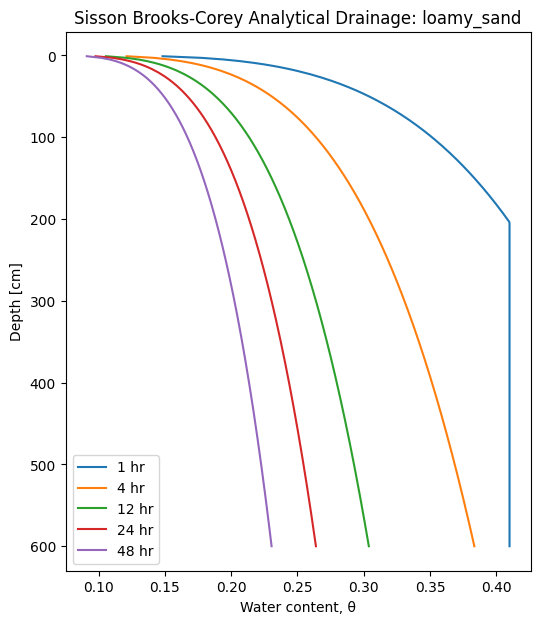

In [276]:
soil_name = "loamy_sand"
preset_soils = known_soils[soil_name]
bc_n = preset_soils["bc_n_fitted"]
q0 = preset_soils["Ks"]

plt.figure(figsize=(6, 7))

for t in times:

    theta = theta_brooks_corey_sisson_piecewise(
        z=z,
        t=t,
        theta_r=preset_soils["theta_r"],
        theta_s=preset_soils["theta_s"],
        Ks=preset_soils["Ks"],
        bc_n=bc_n,
        q0=q0
    )
    plt.plot(theta, z, label=f"{t} hr")

plt.gca().invert_yaxis()
plt.xlabel("Water content, θ")
plt.ylabel("Depth [cm]")
plt.title(f"Sisson Brooks-Corey Analytical Drainage: {soil_name}")
plt.legend()
plt.show()

### 3.2 Plot For all soils in the KNOWN dictionary over all times to check

In [277]:
"""for soil_name, soil in known_soils.items():

    bc_n = soil["bc_n_fitted"]
    q0 = soil["Ks"]

    plt.figure(figsize=(6, 7))

    for t in times:
        theta = theta_brooks_corey_sisson_piecewise(
            z=z,
            t=t,
            theta_r=soil["theta_r"],
            theta_s=soil["theta_s"],
            Ks=soil["Ks"],
            bc_n=bc_n,
            q0=q0,
            debug=False
        )

        plt.plot(theta, z, label=f"{t} hr")

    plt.gca().invert_yaxis()
    plt.xlabel("Water content, θ")
    plt.ylabel("Depth [cm]")
    plt.title(f"Sisson Brooks-Corey drainage: {soil_name}")
    plt.legend()
    plt.show()"""

'for soil_name, soil in known_soils.items():\n\n    bc_n = soil["bc_n_fitted"]\n    q0 = soil["Ks"]\n\n    plt.figure(figsize=(6, 7))\n\n    for t in times:\n        theta = theta_brooks_corey_sisson_piecewise(\n            z=z,\n            t=t,\n            theta_r=soil["theta_r"],\n            theta_s=soil["theta_s"],\n            Ks=soil["Ks"],\n            bc_n=bc_n,\n            q0=q0,\n            debug=False\n        )\n\n        plt.plot(theta, z, label=f"{t} hr")\n\n    plt.gca().invert_yaxis()\n    plt.xlabel("Water content, θ")\n    plt.ylabel("Depth [cm]")\n    plt.title(f"Sisson Brooks-Corey drainage: {soil_name}")\n    plt.legend()\n    plt.show()'

## HERE IS THE STOP POINT

Use Archies Law to convert water content to electrical conductivity. 

In [278]:
theta_results[scenario_name][t]
### how to get these into a matrix???

array([0.3628938 , 0.37929757, 0.38726503, 0.392636  , 0.39671274,
       0.40000856, 0.40278008, 0.40517451, 0.40728428, 0.40917134,
       0.41087924, 0.41243983, 0.41387708, 0.41520952, 0.41645176,
       0.41761553, 0.4187104 , 0.41974427, 0.42072375, 0.42165441,
       0.42254103, 0.42338768, 0.4241979 , 0.42497478, 0.42572103,
       0.42643903, 0.4271309 , 0.42779853, 0.42844359, 0.42906761,
       0.42967196, 0.43025786, 0.43082644, 0.43137872, 0.43191564,
       0.43243805, 0.43294673, 0.43344241, 0.43392575, 0.43439737,
       0.43485784, 0.43530769, 0.43574742, 0.43617747, 0.43659827,
       0.43701024, 0.43741373, 0.43780911, 0.4381967 , 0.43857681,
       0.43894973, 0.43931574, 0.43967509, 0.44002803, 0.44037479,
       0.44071559, 0.44105064, 0.44138012, 0.44170424, 0.44202316,
       0.44233706, 0.44264609, 0.44295042, 0.44325017, 0.44354549,
       0.44383652, 0.44412339, 0.4444062 , 0.44468508, 0.44496014,
       0.44523149, 0.44549922, 0.44576344, 0.44602423, 0.44628

In [279]:
def theta_to_conductivity(theta, sigma_w, m_archie):
    """
    Convert volumetric water content to bulk electrical
    conductivity using simplified Archie's law.
    """
    sigma_bulk = sigma_w * theta**m_archie

    return sigma_bulk


# Archie parameters used for all scenarios
sigma_w = 0.1       # Water conductivity [S/m] - adjust as needed
m_archie = 1.5      # Cementation exponent - adjust as needed


# Convert every analytical theta profile to conductivity
sigma_matrices = {}

for scenario_name, time_dict in theta_results.items():

    conductivity_profiles = {}

    for t, theta_profile in time_dict.items():

        sigma_profile = theta_to_conductivity(
            theta=theta_profile,
            sigma_w=sigma_w,
            m_archie=m_archie
        )

        conductivity_profiles[t] = sigma_profile

    sigma_matrix = pd.DataFrame(
        conductivity_profiles,
        index=z
    )

    sigma_matrix.index.name = "depth_cm"

    sigma_matrices[scenario_name] = sigma_matrix

In [280]:
first_scenario = next(iter(sigma_matrices))

print("Displayed scenario:", first_scenario)
display(sigma_matrices[first_scenario].head())

Displayed scenario: sand


,1,4,12,24,48
depth_cm,,,,,
1.000000,0.003834,0.002726,0.002175,0.001925,0.001728
3.003344,0.005246,0.003555,0.002727,0.002354,0.002064
5.006689,0.006143,0.004076,0.003070,0.002620,0.002271
7.010033,0.006841,0.004479,0.003335,0.002824,0.002429
9.013378,0.007429,0.004817,0.003556,0.002994,0.002561


### 4. SimPEG Forward Model 
#### 4.1 Layered model at 1 time
extract one ec profile at one time step and determine expected TEM response, create a 1D layered TDEM forward model using SimPEG tutorial

In [ ]:
# SimPEG TEM forward model from the electrical conductivity matrix

def build_tem_simulation(
    layer_thicknesses_m,
    loop_side_length_m=20.0,
    height_m=0.0,
    tem_times=None
):
    """Build one layered TDEM simulation for all ensemble profiles."""

    if tem_times is None:
        tem_times = np.logspace(-7, -2, 61)

    layer_thicknesses_m = np.asarray(
        layer_thicknesses_m,
        dtype=float
    )

    n_layers = len(layer_thicknesses_m) + 1

    receiver = tdem.receivers.PointMagneticFluxDensity(   ### OR receiver = tdem.receivers.PointMagneticFluxTimeDerivative(
        locations=np.array([[0.0, 0.0, height_m]]),
        times=tem_times,
        orientation="z"
    )

    # Equivalent-area circular loop for a 20 m x 20 m square loop
    loop_area = loop_side_length_m**2
    loop_radius = np.sqrt(loop_area / np.pi)

    source = tdem.sources.CircularLoop(
        receiver_list=[receiver],
        location=np.array([0.0, 0.0, height_m]),
        radius=loop_radius,
        orientation="z",
        waveform=tdem.sources.StepOffWaveform()
    )

    survey = tdem.Survey([source])

    conductivity_map = maps.IdentityMap(nP=n_layers)

    simulation = tdem.simulation_1d.Simulation1DLayered(
        survey=survey,
        sigmaMap=conductivity_map,
        thicknesses=layer_thicknesses_m
    )

    return simulation, tem_times

### 4.2 Layered model at all times

In [294]:
# Run TEM forward model for every HYDRUS time

# All analytical scenarios use the same depth grid
first_sigma_matrix = next(iter(sigma_matrices.values()))

depth_m = first_sigma_matrix.index.to_numpy() / 100.0
layer_thicknesses_m = np.diff(depth_m)

tem_simulation, tem_times = build_tem_simulation(
    layer_thicknesses_m=layer_thicknesses_m,
    loop_side_length_m=20.0,
    height_m=0.0
)

tem_results = {}

for scenario_name, sigma_matrix in sigma_matrices.items():

    tem_results[scenario_name] = {}

    for drainage_time in sigma_matrix.columns:

        conductivity_profile = (
            sigma_matrix[drainage_time].to_numpy(dtype=float)
        )

        response = tem_simulation.dpred(conductivity_profile)

        tem_results[scenario_name][drainage_time] = response

In [295]:
tem_response_matrices = {}

for scenario_name, time_dict in tem_results.items():

    response_matrix = pd.DataFrame(
        time_dict,
        index=tem_times
    )

    response_matrix.index.name = "TEM_time_s"

    tem_response_matrices[scenario_name] = response_matrix

### 4.3 Plot
#### response shown as TEM response over time as that is how the HYDRUS simulations have been done. Can be adjusted to give a singular response profile if desired

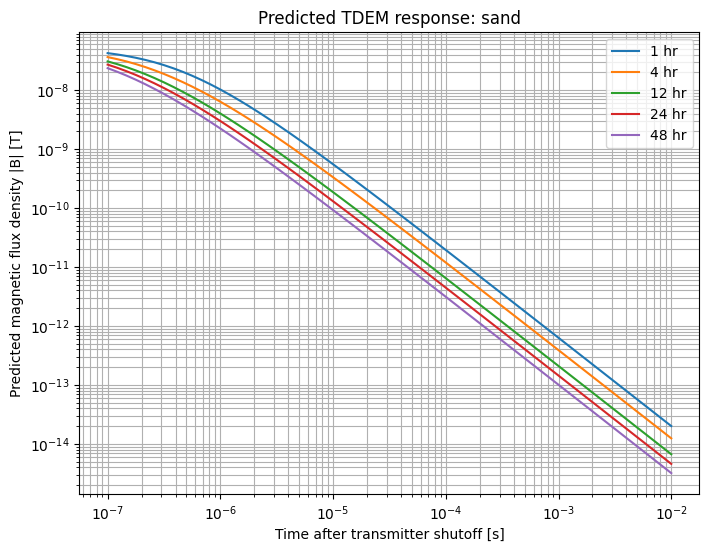

In [ ]:
scenario_to_plot = next(iter(tem_response_matrices))
response_matrix = tem_response_matrices[scenario_to_plot]

plt.figure(figsize=(8, 6))

for drainage_time in response_matrix.columns:
    plt.loglog(
        response_matrix.index,
        np.abs(response_matrix[drainage_time]),
        label=f"{drainage_time} hr"
    )

plt.xlabel("Time after transmitter shutoff [s]")
plt.ylabel("Predicted magnetic flux density |B| [T]") ### OR plt.ylabel("|dB/dt| [T/s]")
plt.title(f"Predicted TDEM response: {scenario_to_plot}")
plt.legend()
plt.grid(True, which="both")
plt.show()

For now, we are only looking for TDEM Response for clustering 6/19/26

Later... I could convert backwards to the electrical conductivity profile, then the water content profile, then......figure out the vG parameters